In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/credit_card_fraud_10k.csv")

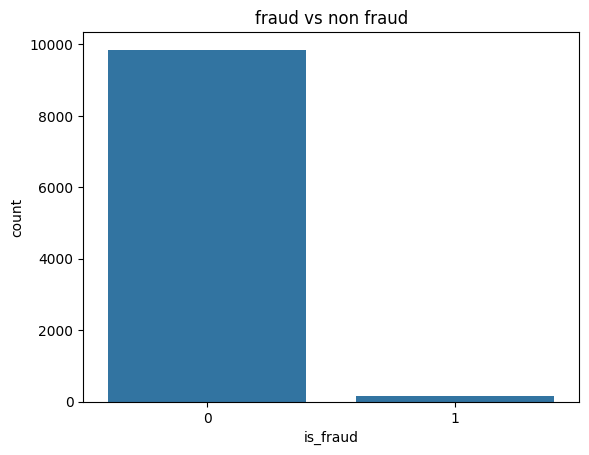

<Figure size 640x480 with 0 Axes>

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='is_fraud',data=df)
plt.title("fraud vs non fraud")
plt.show()
plt.savefig("../images/fraud by non fraud")

In [4]:
df['is_fraud'].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

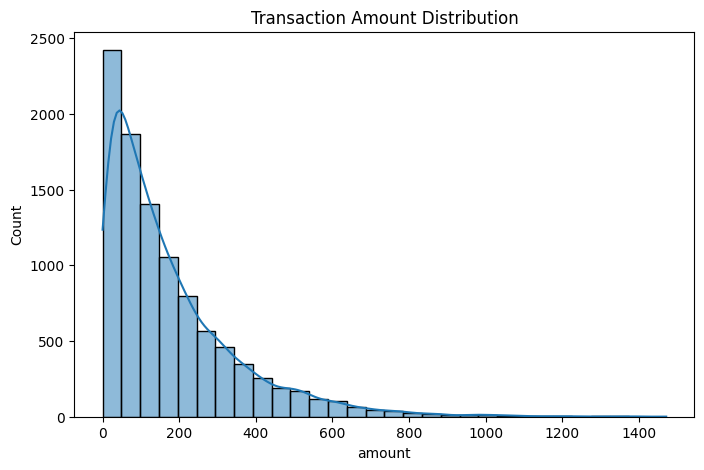

<Figure size 640x480 with 0 Axes>

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=30, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()
plt.savefig("../images/Transaction Amount Distribution")

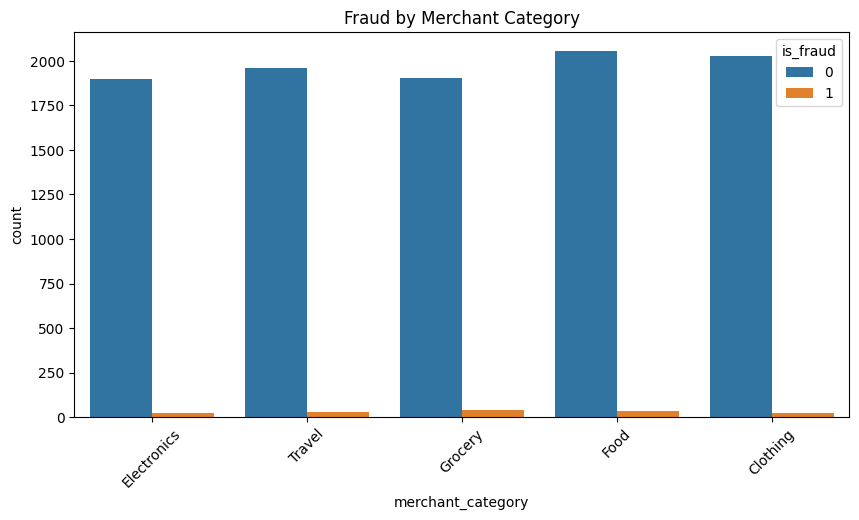

In [6]:
plt.figure(figsize=(10,5))
sns.countplot(x='merchant_category', hue='is_fraud', data=df)
plt.xticks(rotation=45)
plt.title("Fraud by Merchant Category")
plt.show()
plt.s

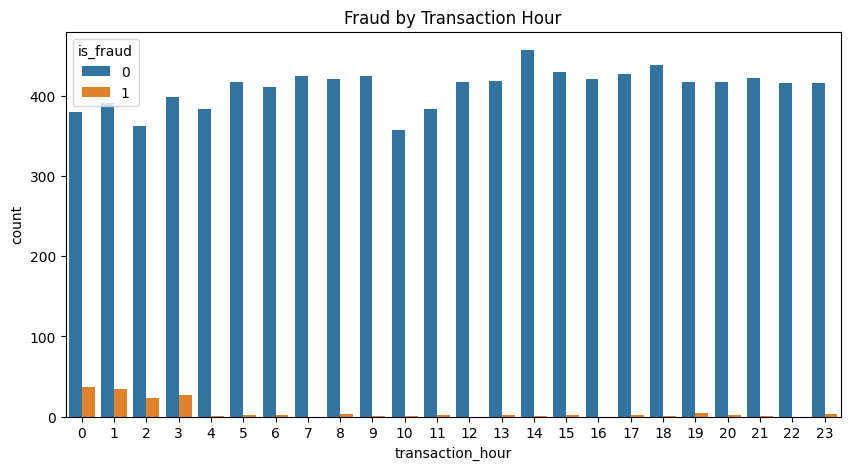

<Figure size 640x480 with 0 Axes>

In [39]:
plt.figure(figsize=(10,5))
sns.countplot(x='transaction_hour', hue='is_fraud', data=df)
plt.title("Fraud by Transaction Hour")
plt.show()
plt.savefig("../images/Fraud by Transaction Hour")

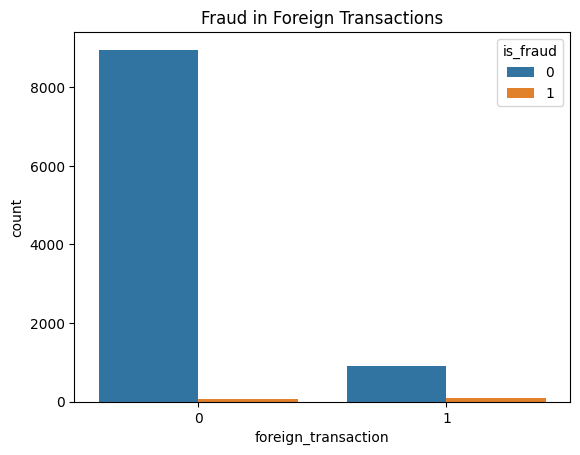

<Figure size 640x480 with 0 Axes>

In [38]:
sns.countplot(x='foreign_transaction', hue='is_fraud', data=df)
plt.title("Fraud in Foreign Transactions")
plt.show()
plt.savefig("../images/Fraud in Foreign Transactions")

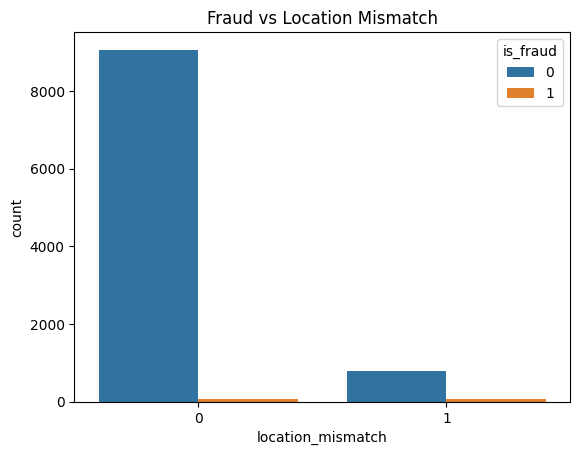

<Figure size 640x480 with 0 Axes>

In [37]:
sns.countplot(x='location_mismatch', hue='is_fraud', data=df)
plt.title("Fraud vs Location Mismatch")
plt.show()
plt.savefig("../images/Fraud vs Location Mismatch")

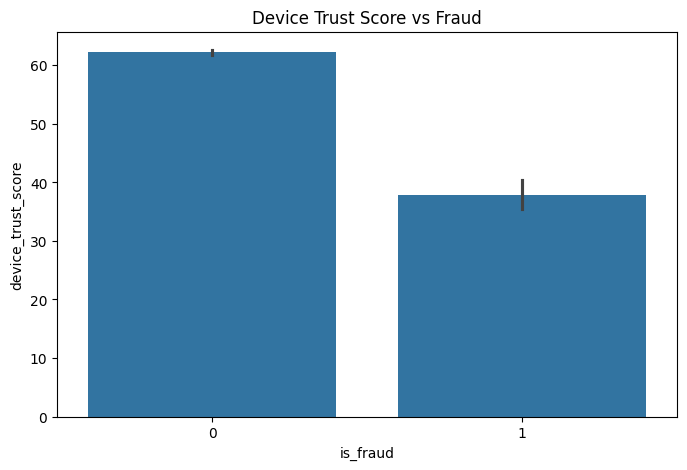

<Figure size 640x480 with 0 Axes>

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(x='is_fraud', y='device_trust_score', data=df)
plt.title("Device Trust Score vs Fraud")
plt.show()
plt.savefig("../images/Device Trust Score vs Fraud")

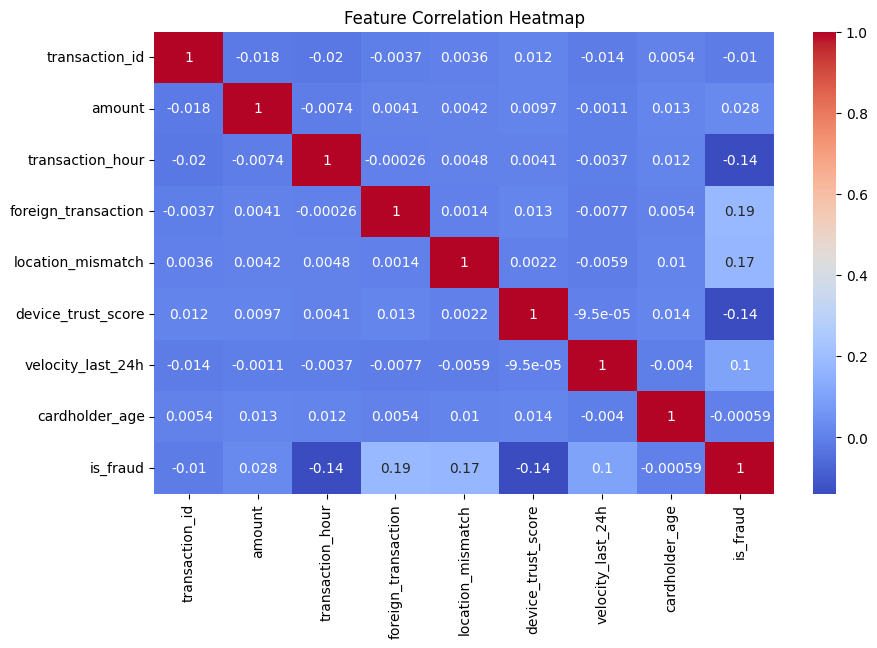

<Figure size 640x480 with 0 Axes>

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()
plt.savefig("../images/Feature Correlation Heatmap")

In [12]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

print(X.head())
print(y.head())

   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  
0                  3              40  
1                  1              64  
2                  1              61  
3                  3              34  
4                  0   

In [13]:
X.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age'],
      dtype='object')

In [14]:
X = pd.get_dummies(X, columns=['merchant_category'], drop_first=True)
print(X.head())
print(X.shape)

   transaction_id  amount  transaction_hour  foreign_transaction  \
0               1   84.47                22                    0   
1               2  541.82                 3                    1   
2               3  237.01                17                    0   
3               4  164.33                 4                    0   
4               5   30.53                15                    0   

   location_mismatch  device_trust_score  velocity_last_24h  cardholder_age  \
0                  0                  66                  3              40   
1                  0                  87                  1              64   
2                  0                  49                  1              61   
3                  1                  72                  3              34   
4                  0                  79                  0              44   

   merchant_category_Electronics  merchant_category_Food  \
0                           True                   False

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 12)
(2000, 12)


In [16]:
X_train.shape
X_test.shape

(2000, 12)

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [18]:
y_pred = rf_model.predict(X_test)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1970    0]
 [  14   16]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.53      0.70        30

    accuracy                           0.99      2000
   macro avg       1.00      0.77      0.85      2000
weighted avg       0.99      0.99      0.99      2000



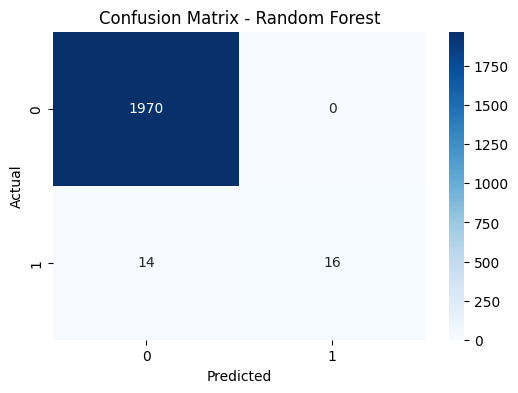

<Figure size 640x480 with 0 Axes>

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
plt.savefig("../images/Confusion Matrix - Random Forest")

In [21]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

is_fraud
0    7879
1     121
Name: count, dtype: int64
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [23]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test)

print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

[[1942   28]
 [   7   23]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1970
           1       0.45      0.77      0.57        30

    accuracy                           0.98      2000
   macro avg       0.72      0.88      0.78      2000
weighted avg       0.99      0.98      0.98      2000



In [24]:
X = X.drop('transaction_id', axis=1)

device_trust_score           0.286083
transaction_hour             0.242995
velocity_last_24h            0.091717
transaction_id               0.076524
amount                       0.054407
cardholder_age               0.047360
merchant_category_Grocery    0.047225
merchant_category_Food       0.043548
foreign_transaction          0.032723
merchant_category_Travel     0.029800
dtype: float64


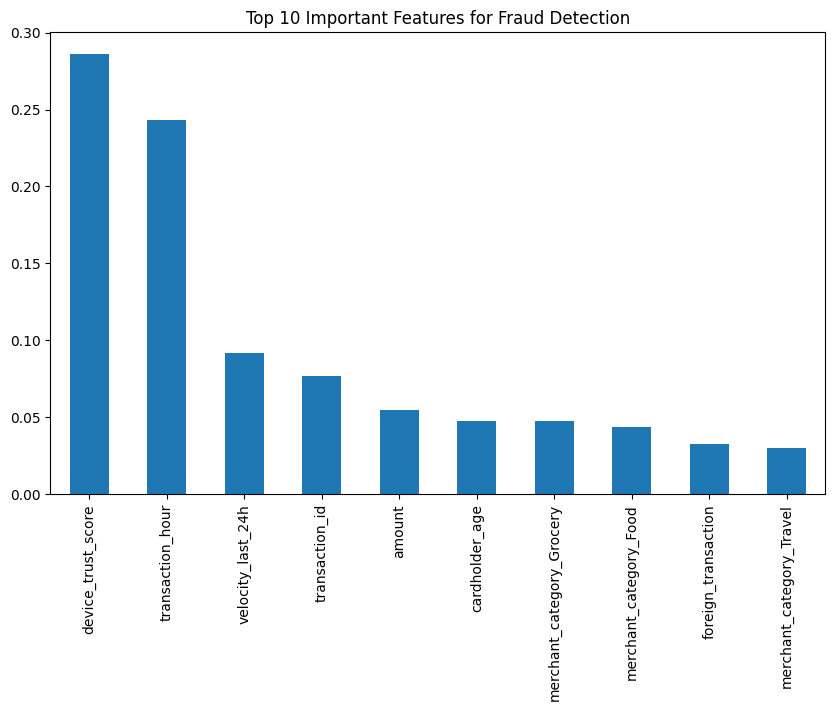

<Figure size 640x480 with 0 Axes>

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf_smote.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features for Fraud Detection")
plt.show()
plt.savefig("../images/Top 10 Important Features for Fraud Detection")

In [26]:
import joblib

joblib.dump(rf_smote, "fraud_model.pkl")

['fraud_model.pkl']